In [2]:
import pandas as pd

# Buat dataset mahasiswa
data = {
    'Nama': ['Andi', 'Budi', 'Citra', 'Dina', 'Eka'],
    'Umur': [20, 21, 22, 20, 23],
    'Jurusan': ['TI', 'SI', 'TI', 'MI', 'SI'],
    'IPK': [3.5, 3.2, 3.8, 3.1, 3.6]
}

df = pd.DataFrame(data)
df


,Nama,Umur,Jurusan,IPK
0,Andi,20,TI,3.5
1,Budi,21,SI,3.2
2,Citra,22,TI,3.8
3,Dina,20,MI,3.1
4,Eka,23,SI,3.6


Matplotlib is building the font cache; this may take a moment.
C:\Users\USER\AppData\Local\Temp\ipykernel_11628\1342002178.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Nama', y='IPK', data=df, palette='coolwarm')


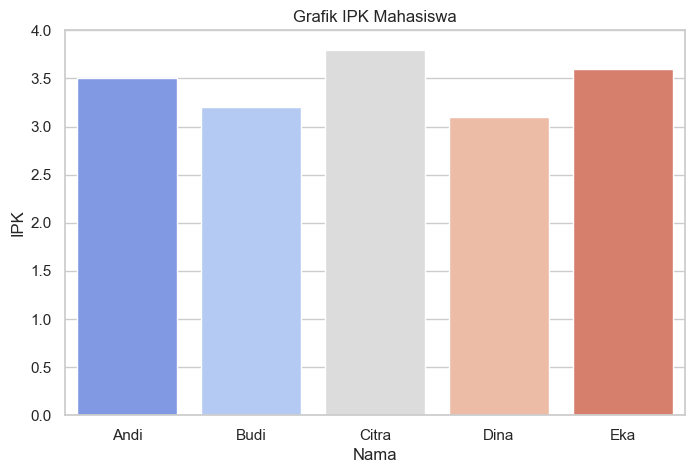

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gunakan style yang rapi
sns.set(style="whitegrid")

# Buat grafik batang IPK mahasiswa
plt.figure(figsize=(8, 5))
sns.barplot(x='Nama', y='IPK', data=df, palette='coolwarm')

plt.title('Grafik IPK Mahasiswa')
plt.xlabel('Nama')
plt.ylabel('IPK')
plt.ylim(0, 4.0)
plt.show()


In [4]:
import pandas as pd

# Dataset dengan label
data = {
    'Nama': ['Andi', 'Budi', 'Citra', 'Dina', 'Eka'],
    'Umur': [20, 21, 22, 20, 23],
    'Jurusan': ['TI', 'SI', 'TI', 'MI', 'SI'],
    'IPK': [3.5, 3.2, 3.8, 3.1, 3.6],
    'Lulus_Tepat_Waktu': ['Ya', 'Tidak', 'Ya', 'Tidak', 'Ya']
}

df = pd.DataFrame(data)
df


,Nama,Umur,Jurusan,IPK,Lulus_Tepat_Waktu
0,Andi,20,TI,3.5,Ya
1,Budi,21,SI,3.2,Tidak
2,Citra,22,TI,3.8,Ya
3,Dina,20,MI,3.1,Tidak
4,Eka,23,SI,3.6,Ya


In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode kolom kategorikal
le_jurusan = LabelEncoder()
df['Jurusan_encoded'] = le_jurusan.fit_transform(df['Jurusan'])

le_label = LabelEncoder()
df['Label_encoded'] = le_label.fit_transform(df['Lulus_Tepat_Waktu'])


In [7]:
from sklearn.tree import DecisionTreeClassifier

# Fitur dan label
X = df[['Umur', 'IPK', 'Jurusan_encoded']]
y = df['Label_encoded']

# Buat model dan latih
model = DecisionTreeClassifier()
model.fit(X, y)


DecisionTreeClassifier()

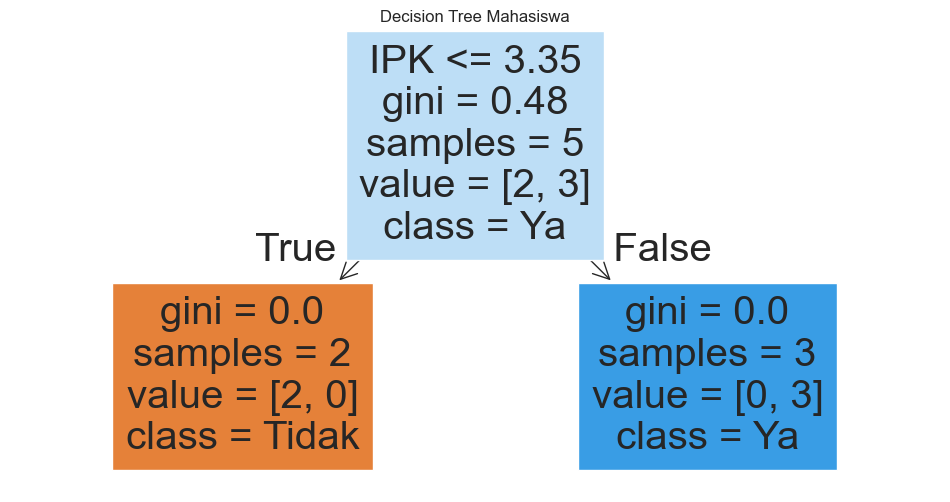

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=['Umur', 'IPK', 'Jurusan'], 
          class_names=le_label.classes_, filled=True)
plt.title("Decision Tree Mahasiswa")
plt.show()


In [9]:
# Encode jurusan baru
jurusan_baru = 'TI'
jurusan_encoded = le_jurusan.transform([jurusan_baru])[0]

# Data mahasiswa baru
mahasiswa_baru = [[21, 3.4, jurusan_encoded]]

# Prediksi
prediksi = model.predict(mahasiswa_baru)
label_prediksi = le_label.inverse_transform(prediksi)

print("Prediksi kelulusan tepat waktu:", label_prediksi[0])


Prediksi kelulusan tepat waktu: Ya


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [10]:
# Banyak mahasiswa baru
data_baru = pd.DataFrame({
    'Umur': [20, 23],
    'IPK': [3.6, 2.9],
    'Jurusan': ['SI', 'TI']
})

# Encode jurusan
data_baru['Jurusan_encoded'] = le_jurusan.transform(data_baru['Jurusan'])

# Prediksi
X_baru = data_baru[['Umur', 'IPK', 'Jurusan_encoded']]
prediksi_baru = model.predict(X_baru)
data_baru['Prediksi_Lulus'] = le_label.inverse_transform(prediksi_baru)

data_baru


,Umur,IPK,Jurusan,Jurusan_encoded,Prediksi_Lulus
0,20,3.6,SI,1,Ya
1,23,2.9,TI,2,Tidak
